In [1]:
from binance.client import Client
import pandas as pd
import mplfinance as mpf

In [2]:
from tvDatafeed import TvDatafeed, Interval
import pandas as pd
import numpy as np
import pandas_ta as ta
import vectorbt as vbt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
tv = TvDatafeed()

you are using nologin method, data you access may be limited


In [4]:
import plotly.offline as pyo
import plotly.graph_objs as go
import plotly.express as px

In [5]:
tv.get_hist(symbol='OR',exchange='SET',interval=Interval.in_daily,n_bars=20000)

,symbol,open,high,low,close,volume
datetime,,,,,,
2021-02-10 09:00:00,SET:OR,18.000000,18.000000,18.000000,18.000000,0.000000e+00
2021-02-11 09:00:00,SET:OR,26.500000,29.500000,22.100000,29.250000,1.818126e+09
2021-02-15 09:00:00,SET:OR,30.750000,36.500000,30.500000,34.000000,1.149683e+09
2021-02-16 09:00:00,SET:OR,35.000000,35.000000,32.000000,32.750000,4.793771e+08
2021-02-17 09:00:00,SET:OR,31.500000,32.500000,29.500000,29.500000,3.383854e+08
...,...,...,...,...,...,...
2023-04-05 09:00:00,SET:OR,21.299999,21.400000,21.000000,21.000000,1.282303e+07
2023-04-07 09:00:00,SET:OR,21.100000,21.200001,21.000000,21.000000,6.107677e+06
2023-04-10 09:00:00,SET:OR,21.000000,21.400000,21.000000,21.299999,8.995529e+06


In [6]:
df = tv.get_hist(symbol='BTCUSDT',exchange='BINANCE',interval=Interval.in_daily,n_bars=20000)

df['fast_ema'] = df.ta.ema(12)
df['slow_ema'] = df.ta.ema(26)

long_entries = df['fast_ema'].vbt.crossed_above(df['slow_ema'])
long_exits = df['fast_ema'].vbt.crossed_below(df['slow_ema'])

port = vbt.Portfolio.from_signals(df.close,
                                    entries = long_entries,
                                    exits = long_exits,
                                    freq = 'D',
                                    init_cash = 10000,
                                    fees = 0.0025,
                                    slippage = 0.0025)

In [7]:
df['long_entries'] = long_entries
df['long_exits'] = long_exits
df

,symbol,open,high,low,close,volume,fast_ema,slow_ema,long_entries,long_exits
datetime,,,,,,,,,,
2017-08-17 07:00:00,BINANCE:BTCUSDT,4261.48,4485.39,4200.74,4285.08,795.150377,NaN,NaN,False,False
2017-08-18 07:00:00,BINANCE:BTCUSDT,4285.08,4371.52,3938.77,4108.37,1199.888264,NaN,NaN,False,False
2017-08-19 07:00:00,BINANCE:BTCUSDT,4108.37,4184.69,3850.00,4139.98,381.309763,NaN,NaN,False,False
2017-08-20 07:00:00,BINANCE:BTCUSDT,4120.98,4211.08,4032.62,4086.29,467.083022,NaN,NaN,False,False
2017-08-21 07:00:00,BINANCE:BTCUSDT,4069.13,4119.62,3911.79,4016.00,691.743060,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...
2023-04-08 07:00:00,BINANCE:BTCUSDT,27906.34,28154.99,27859.02,27938.38,19479.967350,27890.901202,27080.067234,False,False
2023-04-09 07:00:00,BINANCE:BTCUSDT,27938.38,28530.00,27800.00,28323.76,32531.161010,27957.494863,27172.192624,False,False
2023-04-10 07:00:00,BINANCE:BTCUSDT,28323.76,29770.00,28170.00,29637.34,67754.062200,28215.932576,27354.796133,False,False


In [8]:
df.loc[df.long_entries== True,'entry_position'] = df.low*0.90
df.loc[df.long_exits== True,'exit_position'] = df.high*1.10

In [9]:
df

,symbol,open,high,low,close,volume,fast_ema,slow_ema,long_entries,long_exits,entry_position,exit_position
datetime,,,,,,,,,,,,
2017-08-17 07:00:00,BINANCE:BTCUSDT,4261.48,4485.39,4200.74,4285.08,795.150377,NaN,NaN,False,False,NaN,NaN
2017-08-18 07:00:00,BINANCE:BTCUSDT,4285.08,4371.52,3938.77,4108.37,1199.888264,NaN,NaN,False,False,NaN,NaN
2017-08-19 07:00:00,BINANCE:BTCUSDT,4108.37,4184.69,3850.00,4139.98,381.309763,NaN,NaN,False,False,NaN,NaN
2017-08-20 07:00:00,BINANCE:BTCUSDT,4120.98,4211.08,4032.62,4086.29,467.083022,NaN,NaN,False,False,NaN,NaN
2017-08-21 07:00:00,BINANCE:BTCUSDT,4069.13,4119.62,3911.79,4016.00,691.743060,NaN,NaN,False,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-04-08 07:00:00,BINANCE:BTCUSDT,27906.34,28154.99,27859.02,27938.38,19479.967350,27890.901202,27080.067234,False,False,NaN,NaN
2023-04-09 07:00:00,BINANCE:BTCUSDT,27938.38,28530.00,27800.00,28323.76,32531.161010,27957.494863,27172.192624,False,False,NaN,NaN
2023-04-10 07:00:00,BINANCE:BTCUSDT,28323.76,29770.00,28170.00,29637.34,67754.062200,28215.932576,27354.796133,False,False,NaN,NaN


In [10]:
# df['Port_cum_return'] = port.cumulative_returns().to_frame(name='cumulative_returns').cumulative_returns+1
port.cumulative_returns()

datetime
2017-08-17 07:00:00     0.000000
2017-08-18 07:00:00     0.000000
2017-08-19 07:00:00     0.000000
2017-08-20 07:00:00     0.000000
2017-08-21 07:00:00     0.000000
                         ...    
2023-04-08 07:00:00    14.295860
2023-04-09 07:00:00    14.506850
2023-04-10 07:00:00    15.226016
2023-04-11 07:00:00    15.534295
2023-04-12 07:00:00    15.386189
Length: 2065, dtype: float64

In [11]:
port.cumulative_returns().to_frame(name='cumulative_returns').cumulative_returns+1

datetime
2017-08-17 07:00:00     1.000000
2017-08-18 07:00:00     1.000000
2017-08-19 07:00:00     1.000000
2017-08-20 07:00:00     1.000000
2017-08-21 07:00:00     1.000000
                         ...    
2023-04-03 07:00:00    15.220099
2023-04-04 07:00:00    15.420189
2023-04-05 07:00:00    15.422674
2023-04-06 07:00:00    15.348112
2023-04-07 07:00:00    15.267698
Name: cumulative_returns, Length: 2060, dtype: float64

In [15]:
df_daily_returns = df['close'].pct_change()
# df['cum_returns'] = (df_daily_returns + 1).cumprod()
(df_daily_returns + 1).cumprod().head(30).fillna(0).round(2).to_list()

[0.0,
 0.96,
 0.97,
 0.95,
 0.94,
 0.94,
 0.96,
 1.01,
 1.0,
 1.01,
 1.01,
 1.02,
 1.07,
 1.06,
 1.1,
 1.13,
 1.04,
 1.05,
 0.96,
 1.02,
 1.08,
 1.09,
 1.0,
 0.99,
 0.96,
 0.98,
 0.97,
 0.92,
 0.74,
 0.86]

In [12]:
port.plot().show() 

In [6]:
port.stats()

Start                                2017-08-17 07:00:00
End                                  2023-04-05 07:00:00
Period                                2058 days 00:00:00
Start Value                                      10000.0
End Value                                  156327.555848
Total Return [%]                             1463.275558
Benchmark Return [%]                           566.35232
Max Gross Exposure [%]                             100.0
Total Fees Paid                             12854.371023
Max Drawdown [%]                               64.711144
Max Drawdown Duration                  722 days 00:00:00
Total Trades                                          29
Total Closed Trades                                   28
Total Open Trades                                      1
Open Trade PnL                              22701.434583
Win Rate [%]                                   32.142857
Best Trade [%]                                364.017833
Worst Trade [%]                

In [20]:
port.stats()["Sharpe Ratio"]

1.1937103442065748

In [7]:
df_daily_returns = df['close'].pct_change()
cum_returns = (df_daily_returns + 1).cumprod()

<Axes: xlabel='datetime'>

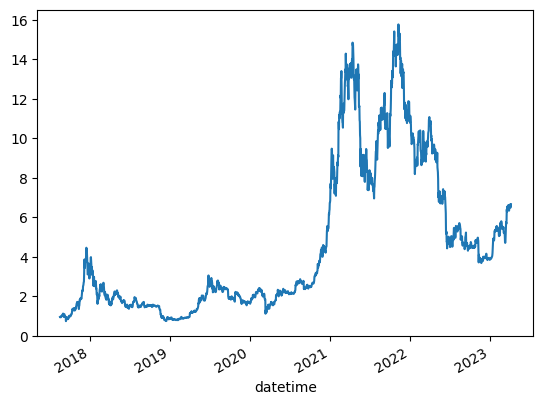

In [8]:
cum_returns.plot()

<Axes: xlabel='datetime'>

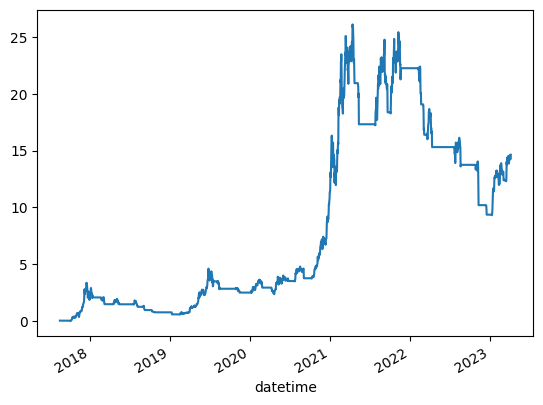

In [9]:
port.cumulative_returns().plot()

In [15]:
# port.cumulative_returns().to_list()
port.cumulative_returns().index.astype(str).to_list()

['2017-08-17 07:00:00',
 '2017-08-18 07:00:00',
 '2017-08-19 07:00:00',
 '2017-08-20 07:00:00',
 '2017-08-21 07:00:00',
 '2017-08-22 07:00:00',
 '2017-08-23 07:00:00',
 '2017-08-24 07:00:00',
 '2017-08-25 07:00:00',
 '2017-08-26 07:00:00',
 '2017-08-27 07:00:00',
 '2017-08-28 07:00:00',
 '2017-08-29 07:00:00',
 '2017-08-30 07:00:00',
 '2017-08-31 07:00:00',
 '2017-09-01 07:00:00',
 '2017-09-02 07:00:00',
 '2017-09-03 07:00:00',
 '2017-09-04 07:00:00',
 '2017-09-05 07:00:00',
 '2017-09-06 07:00:00',
 '2017-09-07 07:00:00',
 '2017-09-08 07:00:00',
 '2017-09-09 07:00:00',
 '2017-09-10 07:00:00',
 '2017-09-11 07:00:00',
 '2017-09-12 07:00:00',
 '2017-09-13 07:00:00',
 '2017-09-14 07:00:00',
 '2017-09-15 07:00:00',
 '2017-09-16 07:00:00',
 '2017-09-17 07:00:00',
 '2017-09-18 07:00:00',
 '2017-09-19 07:00:00',
 '2017-09-20 07:00:00',
 '2017-09-21 07:00:00',
 '2017-09-22 07:00:00',
 '2017-09-23 07:00:00',
 '2017-09-24 07:00:00',
 '2017-09-25 07:00:00',
 '2017-09-26 07:00:00',
 '2017-09-27 07:

In [29]:
port.cumulative_returns().info(memory_usage="deep")

<class 'pandas.core.series.Series'>
DatetimeIndex: 2058 entries, 2017-08-17 07:00:00 to 2023-04-05 07:00:00
Series name: None
Non-Null Count  Dtype  
--------------  -----  
2058 non-null   float64
dtypes: float64(1)
memory usage: 96.7 KB


In [30]:
port.trades.records_readable

,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id
0,0,0,2.272505,2017-09-30 07:00:00,4389.456275,24.937656,2018-01-14 07:00:00,13441.302525,76.363576,20469.066718,2.052024,Long,Closed,0
1,1,0,2.904623,2018-02-21 07:00:00,10463.694000,75.982710,2018-02-22 07:00:00,9786.512400,71.065317,-2114.005132,-0.069555,Long,Closed,1
2,2,0,2.669478,2018-02-27 07:00:00,10595.462600,70.710877,2018-03-09 07:00:00,9203.932500,61.424230,-3846.793622,-0.136004,Long,Closed,2
3,3,0,2.945903,2018-04-19 07:00:00,8298.695000,61.117875,2018-05-16 07:00:00,8309.175000,61.195058,-91.439870,-0.003740,Long,Closed,3
4,4,0,3.320178,2018-07-17 07:00:00,7335.733600,60.889846,2018-08-07 07:00:00,6703.259850,55.640033,-2216.455044,-0.091003,Long,Closed,4
5,5,0,3.141672,2018-08-29 07:00:00,7048.798050,55.362526,2018-09-08 07:00:00,6169.587375,48.457048,-2866.011016,-0.129420,Long,Closed,5
6,6,0,2.908132,2018-10-07 07:00:00,6631.798150,48.215367,2018-10-11 07:00:00,6237.048300,45.345405,-1241.545576,-0.064375,Long,Closed,6
7,7,0,2.670670,2018-10-17 07:00:00,6757.742225,45.119243,2018-10-25 07:00:00,6511.769775,43.476965,-745.507371,-0.041308,Long,Closed,7
8,8,0,4.364179,2019-01-08 07:00:00,3965.017825,43.260122,2019-01-10 07:00:00,3576.915300,39.025750,-1776.034902,-0.102637,Long,Closed,8
9,9,0,4.266523,2019-02-12 07:00:00,3640.538650,38.831108,2019-07-19 07:00:00,10478.029275,111.761891,29021.720257,1.868458,Long,Closed,9


In [12]:
# df['long_entries'].head(30).to_list()
# df['long_exits'].head(30).to_list()
df['close'].head(30).to_list()
# df['timestamp']=df.index.astype(str)
# df['timestamp'].head(30).to_list()
# df.index.astype(str).to_list()

[4285.08,
 4108.37,
 4139.98,
 4086.29,
 4016.0,
 4040.0,
 4114.01,
 4316.01,
 4280.68,
 4337.44,
 4310.01,
 4386.69,
 4587.48,
 4555.14,
 4724.89,
 4834.91,
 4472.14,
 4509.08,
 4100.11,
 4366.47,
 4619.77,
 4691.61,
 4282.8,
 4258.81,
 4130.37,
 4208.47,
 4163.72,
 3944.69,
 3189.02,
 3700.0]

In [70]:
cum = port.cumulative_returns().copy()

In [79]:
# cum['timestamp']=cum.index.astype(str)
cum.tail(30).to_list()

[12.362612126469177,
 12.362612126469177,
 12.362612126469177,
 12.362612126469177,
 12.362612126469177,
 12.362612126469177,
 12.362612126469177,
 12.296048782253026,
 12.686471702923091,
 13.998438785528714,
 13.731462914657678,
 14.314743107645501,
 14.174663445761604,
 14.38733969627133,
 13.919513263535501,
 14.491329108364768,
 14.030926580167145,
 14.035569257931453,
 14.312104227123807,
 13.850497230638277,
 13.925042867948179,
 14.520449866652914,
 14.345216155329616,
 14.584374283605792,
 14.577459540662018,
 14.423692739142783,
 14.22009927449507,
 14.42018883139614,
 14.422674415953917,
 14.380479701886099]

In [18]:
# port.drawdown().to_list()
port.drawdown().index.astype(str).to_list()

['2017-08-17 07:00:00',
 '2017-08-18 07:00:00',
 '2017-08-19 07:00:00',
 '2017-08-20 07:00:00',
 '2017-08-21 07:00:00',
 '2017-08-22 07:00:00',
 '2017-08-23 07:00:00',
 '2017-08-24 07:00:00',
 '2017-08-25 07:00:00',
 '2017-08-26 07:00:00',
 '2017-08-27 07:00:00',
 '2017-08-28 07:00:00',
 '2017-08-29 07:00:00',
 '2017-08-30 07:00:00',
 '2017-08-31 07:00:00',
 '2017-09-01 07:00:00',
 '2017-09-02 07:00:00',
 '2017-09-03 07:00:00',
 '2017-09-04 07:00:00',
 '2017-09-05 07:00:00',
 '2017-09-06 07:00:00',
 '2017-09-07 07:00:00',
 '2017-09-08 07:00:00',
 '2017-09-09 07:00:00',
 '2017-09-10 07:00:00',
 '2017-09-11 07:00:00',
 '2017-09-12 07:00:00',
 '2017-09-13 07:00:00',
 '2017-09-14 07:00:00',
 '2017-09-15 07:00:00',
 '2017-09-16 07:00:00',
 '2017-09-17 07:00:00',
 '2017-09-18 07:00:00',
 '2017-09-19 07:00:00',
 '2017-09-20 07:00:00',
 '2017-09-21 07:00:00',
 '2017-09-22 07:00:00',
 '2017-09-23 07:00:00',
 '2017-09-24 07:00:00',
 '2017-09-25 07:00:00',
 '2017-09-26 07:00:00',
 '2017-09-27 07:

In [80]:
df['previous_peeks'] = df['close'].cummax()
df['drowdown'] = (df['close'] - df['previous_peeks'])/df['previous_peeks']

In [87]:
df['drowdown'].tail(30).to_list()
# port.drawdown().tail(30).to_list()

[-0.6785609299434009,
 -0.6984528735152163,
 -0.7015854525594132,
 -0.69706807009999,
 -0.6742415457906996,
 -0.6428999095605341,
 -0.6346522508497859,
 -0.6403500704841392,
 -0.6297893709710788,
 -0.59430146952655,
 -0.6015230023829399,
 -0.5857456324490941,
 -0.5895347010173737,
 -0.5837819394445058,
 -0.596436356280256,
 -0.5809690899023381,
 -0.5934226946932751,
 -0.5932971131195278,
 -0.5858170125417191,
 -0.5983031974579208,
 -0.5962867838869955,
 -0.5801813913283258,
 -0.5849213552798981,
 -0.5784522752256432,
 -0.5786393147629582,
 -0.5827986120274272,
 -0.5883056898375036,
 -0.5828933905736516,
 -0.5828261570424237,
 -0.583967498067036]

In [31]:
port.trades.records_readable.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Exit Trade Id    29 non-null     int32         
 1   Column           29 non-null     int64         
 2   Size             29 non-null     float64       
 3   Entry Timestamp  29 non-null     datetime64[ns]
 4   Avg Entry Price  29 non-null     float64       
 5   Entry Fees       29 non-null     float64       
 6   Exit Timestamp   29 non-null     datetime64[ns]
 7   Avg Exit Price   29 non-null     float64       
 8   Exit Fees        29 non-null     float64       
 9   PnL              29 non-null     float64       
 10  Return           29 non-null     float64       
 11  Direction        29 non-null     object        
 12  Status           29 non-null     object        
 13  Position Id      29 non-null     int32         
dtypes: datetime64[ns](2), float64(7), int32(2), 

In [18]:
# port.trades.records_readable['Exit Trade Id'].to_list()
# port.trades.records_readable['Entry Timestamp'].astype(str).to_list()
port.trades.records_readable

,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id
0,0,0,2.272505,2017-09-30 07:00:00,4389.456275,24.937656,2018-01-14 07:00:00,13441.302525,76.363576,20469.066718,2.052024,Long,Closed,0
1,1,0,2.904623,2018-02-21 07:00:00,10463.694000,75.982710,2018-02-22 07:00:00,9786.512400,71.065317,-2114.005132,-0.069555,Long,Closed,1
2,2,0,2.669478,2018-02-27 07:00:00,10595.462600,70.710877,2018-03-09 07:00:00,9203.932500,61.424230,-3846.793622,-0.136004,Long,Closed,2
3,3,0,2.945903,2018-04-19 07:00:00,8298.695000,61.117875,2018-05-16 07:00:00,8309.175000,61.195058,-91.439870,-0.003740,Long,Closed,3
4,4,0,3.320178,2018-07-17 07:00:00,7335.733600,60.889846,2018-08-07 07:00:00,6703.259850,55.640033,-2216.455044,-0.091003,Long,Closed,4
5,5,0,3.141672,2018-08-29 07:00:00,7048.798050,55.362526,2018-09-08 07:00:00,6169.587375,48.457048,-2866.011016,-0.129420,Long,Closed,5
6,6,0,2.908132,2018-10-07 07:00:00,6631.798150,48.215367,2018-10-11 07:00:00,6237.048300,45.345405,-1241.545576,-0.064375,Long,Closed,6
7,7,0,2.670670,2018-10-17 07:00:00,6757.742225,45.119243,2018-10-25 07:00:00,6511.769775,43.476965,-745.507371,-0.041308,Long,Closed,7
8,8,0,4.364179,2019-01-08 07:00:00,3965.017825,43.260122,2019-01-10 07:00:00,3576.915300,39.025750,-1776.034902,-0.102637,Long,Closed,8
9,9,0,4.266523,2019-02-12 07:00:00,3640.538650,38.831108,2019-07-19 07:00:00,10478.029275,111.761891,29021.720257,1.868458,Long,Closed,9


In [36]:
a = port.trades.records_readable.copy()
new = pd.concat([
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a,
    a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a, a
], ignore_index=True)
new.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16704 entries, 0 to 16703
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Exit Trade Id    16704 non-null  int32         
 1   Column           16704 non-null  int64         
 2   Size             16704 non-null  float64       
 3   Entry Timestamp  16704 non-null  datetime64[ns]
 4   Avg Entry Price  16704 non-null  float64       
 5   Entry Fees       16704 non-null  float64       
 6   Exit Timestamp   16704 non-null  datetime64[ns]
 7   Avg Exit Price   16704 non-null  float64       
 8   Exit Fees        16704 non-null  float64       
 9   PnL              16704 non-null  float64       
 10  Return           16704 non-null  float64       
 11  Direction        16704 non-null  object        
 12  Status           16704 non-null  object        
 13  Position Id      16704 non-null  int32         
dtypes: datetime64[ns](2), float64(7), int3

In [37]:
port.orders.plot().show()

In [38]:
port.orders

In [58]:
t = df[['close', 'long_entries', 'long_exits']].copy()
# t = pd.concat([
#     t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,
#     t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t,t
#     ], ignore_index=True)
t.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2058 entries, 2017-08-17 07:00:00 to 2023-04-05 07:00:00
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   close         2058 non-null   float64
 1   long_entries  2058 non-null   bool   
 2   long_exits    2058 non-null   bool   
dtypes: bool(2), float64(1)
memory usage: 100.7 KB


In [65]:
x = np.array(t['long_entries'].values.tolist())
 
print("Size of the array: ",
      x.size)
 
print("Memory size of one array element in bytes: ",
      x.itemsize)
 
# memory size of numpy array in bytes
print("Memory size of numpy array in bytes:",
      x.size * x.itemsize)

Size of the array:  2058
Memory size of one array element in bytes:  1
Memory size of numpy array in bytes: 2058


In [36]:
strategy = ta.Strategy(
            name = 'ADX and Supertrend',
            description = 'ADX and Supertrend',
            ta = [
                # {'kind': 'supertrend', 'length': 10},
                {'kind': 'macd', 'fast': 12, 'slow': 26, 'signal': 9},
                # {'kind': 'ema', 'length': 50},
                # {'kind': 'rsi', 'length': 14},
                # {'kind': 'bbands', 'length': 14},
                # {'kind': 'atr', 'length': 14}
            ]
        )
data = df.copy()
data.ta.strategy(strategy)

In [37]:
help(ta.bbands)

Help on function bbands in module pandas_ta.volatility.bbands:

bbands(close, length=None, std=None, ddof=0, mamode=None, talib=None, offset=None, **kwargs)
    Bollinger Bands (BBANDS)
    
    A popular volatility indicator by John Bollinger.
    
    Sources:
        https://www.tradingview.com/wiki/Bollinger_Bands_(BB)
    
    Calculation:
        Default Inputs:
            length=5, std=2, mamode="sma", ddof=0
        EMA = Exponential Moving Average
        SMA = Simple Moving Average
        STDEV = Standard Deviation
        stdev = STDEV(close, length, ddof)
        if "ema":
            MID = EMA(close, length)
        else:
            MID = SMA(close, length)
    
        LOWER = MID - std * stdev
        UPPER = MID + std * stdev
    
        BANDWIDTH = 100 * (UPPER - LOWER) / MID
        PERCENT = (close - LOWER) / (UPPER - LOWER)
    
    Args:
        close (pd.Series): Series of 'close's
        length (int): The short period. Default: 5
        std (int): The long 

In [38]:
data

,symbol,open,high,low,close,volume,MACD_12_26_9,MACDh_12_26_9,MACDs_12_26_9
datetime,,,,,,,,,
2017-08-17 07:00:00,BINANCE:BTCUSDT,4261.48,4485.39,4200.74,4285.08,795.150377,NaN,NaN,NaN
2017-08-18 07:00:00,BINANCE:BTCUSDT,4285.08,4371.52,3938.77,4108.37,1199.888264,NaN,NaN,NaN
2017-08-19 07:00:00,BINANCE:BTCUSDT,4108.37,4184.69,3850.00,4139.98,381.309763,NaN,NaN,NaN
2017-08-20 07:00:00,BINANCE:BTCUSDT,4120.98,4211.08,4032.62,4086.29,467.083022,NaN,NaN,NaN
2017-08-21 07:00:00,BINANCE:BTCUSDT,4069.13,4119.62,3911.79,4016.00,691.743060,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2023-04-02 07:00:00,BINANCE:BTCUSDT,28452.74,28530.00,27856.43,28171.87,37365.656920,1169.234435,-32.152827,1201.387262
2023-04-03 07:00:00,BINANCE:BTCUSDT,28171.87,28500.99,27200.24,27800.00,79180.014050,1089.860917,-89.221076,1179.081993
2023-04-04 07:00:00,BINANCE:BTCUSDT,27800.00,28444.44,27662.79,28165.47,49722.556910,1044.407922,-107.739256,1152.147179


In [1]:
indicators = [
        {
            "name": "EMA",
            "description": "EMA",
            "inputs": [
                "close"
            ],
            "params": [
                {
                    "name": "name",
                    "label": "Name",
                    "type": "text",
                    "defaultValue": ""
                },
                {
                    "name": "length",
                    "label": "Length",
                    "type": "number",
                    "defaultValue": 50
                }
            ],
            "indicator": "ema",
            "outputs": [
                {
                    "name": "EMA",
                    "label": "ema",
                    "type": "number"
                }
            ]
        },
        {
            "name": "RSI",
            "description": "RSI",
            "inputs": [
                "close"
            ],
            "params": [
                {
                    "name": "name",
                    "label": "Name",
                    "type": "text",
                    "defaultValue": ""
                },
                {
                    "name": "length",
                    "label": "Length",
                    "type": "number",
                    "defaultValue": 14
                }
            ],
            "indicator": "rsi",
            "outputs": [
                {
                    "name": "RSI",
                    "label": "rsi",
                    "type": "number"
                }
            ]
        },
        {
            "name": "MACD",
            "description": "MACD",
            "inputs": [
                "close"
            ],
            "params": [
                {
                    "name": "name",
                    "label": "Name",
                    "type": "text",
                    "defaultValue": ""
                },
                {
                    "name": "fast",
                    "label": "Fast length", 
                    "type": "number",
                    "defaultValue": 12
                },
                {
                    "name": "slow",
                    "label": "Slow length",
                    "type": "number",
                    "defaultValue": 26
                },
                {
                    "name": "signal",
                    "label": "Signal",
                    "type": "number",
                    "defaultValue": 9
                }
            ],
            "indicator": "macd",
            "outputs": [
                {
                    "name": "MACD",
                    "label": "macd",
                    "graph": "line",
                    "type": "number"
                },
                {
                    "name": "MACDs",
                    "label": "signal",
                    "graph": "line",
                    "type": "number"
                },
                {
                    "name": "MACDh",
                    "label": "histogram",
                    "graph": "hist",
                    "type": "number"
                }
            ]
        },
        {
            "name": "SUPERTREND",
            "description": "SUPERTREND",
            "inputs": [
                "close"
            ],
            "params": [
                {
                    "name": "name",
                    "label": "Name",
                    "type": "text",
                    "defaultValue": ""
                },
                {
                    "name": "length",
                    "label": "Length", 
                    "type": "number",
                    "defaultValue": 7
                }
            ],
            "indicator": "supertrend",
            "outputs": [
                {
                    "name": "SUPERT",
                    "label": "trend",
                    "type": "number"
                },
                {
                    "name": "SUPERTd",
                    "label": "direction",
                    "type": "number"
                },
                {
                    "name": "SUPERTl",
                    "label": "long",
                    "type": "number"
                },
                {
                    "name": "SUPERTs",
                    "label": "short",
                    "type": "number"
                }
            ]
        }
]

In [1]:
import tradingview_ws as td
def callbackFunc(s):
    print(s)

In [2]:
pair = "S501!"

market = "futures" # 'stock' | 'futures' | 'forex' | 'cfd' | 'crypto' | 'index' | 'economic'
username = None
password = None
trading = td.TradingViewWs(pair, market, username, password)
# get quote price
trading.realtime_quote(callbackFunc)

# get ohlcv
# interval = 5
# total_candle = 240 # total candle to calculate indicator ex: EMA, WMA
# trading.realtime_bar_chart(interval, total_candle, callbackFunc)
# trading.realtime_quote(callbackFunc)
trading.realtime(callbackFunc)

{'symbol': 'TFEX:S501!', 'price': 947.5}
{'symbol': 'TFEX:S501!', 'price': 947.6}
{'symbol': 'TFEX:S501!', 'price': 947.7}
{'symbol': 'TFEX:S501!', 'price': 947.3}
{'symbol': 'TFEX:S501!', 'price': 947.5}
{'symbol': 'TFEX:S501!', 'price': 947.4}
{'symbol': 'TFEX:S501!', 'price': 947.5}
{'symbol': 'TFEX:S501!', 'price': 947.4}
{'symbol': 'TFEX:S501!', 'price': 947.3}
{'symbol': 'TFEX:S501!', 'price': 947.4}
{'symbol': 'TFEX:S501!', 'price': 947.3}
{'symbol': 'TFEX:S501!', 'price': 947.4}
{'symbol': 'TFEX:S501!', 'price': 947.3}
{'symbol': 'TFEX:S501!', 'price': 947.2}
{'symbol': 'TFEX:S501!', 'price': 947.1}
{'symbol': 'TFEX:S501!', 'price': 947.2}
{'symbol': 'TFEX:S501!', 'price': 947.4}
{'symbol': 'TFEX:S501!', 'price': 947.0}
{'symbol': 'TFEX:S501!', 'price': 947.1}
{'symbol': 'TFEX:S501!', 'price': 947.2}
{'symbol': 'TFEX:S501!', 'price': 947.3}
{'symbol': 'TFEX:S501!', 'price': 947.2}
{'symbol': 'TFEX:S501!', 'price': 947.3}
{'symbol': 'TFEX:S501!', 'price': 947.2}
{'symbol': 'TFEX